# Parallel Processing Fundamentals
## *Prof. Gary L. Pavlis*

Before we consider seismic processing with MsPASS and dask, I think it will be helpful to look at some simpler examples.   Parallel processing with dask is, itself, a large subject.  I focus here on fundamentals you will need to understand in order to comprehend the more complicated seismic processing examples we will examine later in this session.

Concepts this tutorial aims to help you understand are:
1.  Schedulers and workers and how they interact
2.  The dask bag, which we will use for seismic processing with dask, can thought of as a list of things that do not necessarily fit in memory.
3.  Dask uses lazy/delayed computation.  That means you construct the processing sequence before you actually start it.
4.  The bag map operator applies a function with optional arguments to modify each element in the bag. 

First, we need this little incantation to connect to the dask scheduler that is already running on geolab.   Note if you are reading this outside of the MsPASS short course, this notebook cannot be run without modification outside GeoLab.

In [1]:
# TODO:  this needs to be revised with bug fix pending 
from mspasspy.client import Client
#mspass_client=Client(scheduler_host="tcp://127.0.0.1")
mspass_client = Client()   
db = mspass_client.get_database("ES2026")

2026-06-30 12:06:08,555 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:37741'.
2026-06-30 12:06:08,560 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:33561'.
2026-06-30 12:06:08,561 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:45931'.
2026-06-30 12:06:08,565 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:37923'.


Now run this line.  Click on the hyperlink after the "Dashboard:" tag:

In [3]:
dask_client = mspass_client.get_scheduler()
dask_client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/8787/status,
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 29.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46869,Workers: 0
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33561,Total threads: 1
Dashboard: /user/auth0%7C66620230da0803120dd94aaf/proxy/32821/status,Memory: 7.27 GiB
Nanny: tcp://127.0.0.1:33315,


When you clicked on that link you should now have another tab in your display with the label "Dask: Status".   That provides a window into cluster operations that can help you understand what is going on below.   Keep that tab open as we'll be looking at it repeatedly.

## Trivial example
The first does a trivial calculation but provides a simple example for how to use dask to run a loop in parallel.   I emphasize the calculation is trivial and is not something you would normally try to run in parallel.   It  teaches some additional concepts that should be useful for later.  
1.  The works by harvesting data from the MongoDB database.
2.  It provides the simplest example I can think of to show how a loop over database documents can be transformed into a parallel job.

The actual thing this example does is compute the time difference between end time computed from the sample rate and number of samples to the "endtime" attribute stored in the MongoDB database.   There are cases where that calculation is useful when dealing with timing problems, but all the data here, in fact, have no such issues.  Point is the calculation is trivial but is potentially useful in some contexts.  

First, define a couple of functions.  They aren't really essential, but are helpful to teach the concepts here.  

In [4]:
def extract_tuple(doc):
    """
    Toy function for bag map illustration.  Extracts attributes "starttime", "endtime", "delta",
    and "npts" and returns them in a tuple in that order. 

    Point is to illustrate the content of a bag can change after a map is applied.
    """
    return [doc["starttime"],doc["endtime"],doc["delta"],doc["npts"]]
def endtime_error(time_tuple):
    """
    Takes the output of the function above and computes the time mismatch between 
    the tabulated endtime and that computed from starttime + delta*npts.
    """
    # not necessary to create these temporaries but clearer for a tutorial like this
    stime=time_tuple[0]
    etime=time_tuple[1]
    dt = time_tuple[2]
    npts = time_tuple[3]
    error = etime - (stime + dt*(npts-1))
    return error

In [6]:
# serial version
import time 
t0 = time.time()
err_list=list()
ndocs=db.wf_Seismogram.count_documents({})
cursor = db.wf_Seismogram.find({})
for doc in cursor:
    tup = extract_tuple(doc)
    err = endtime_error(tup)
    err_list.append(err)
t = time.time()
print("Processed ",ndocs," items in ",t-t0," seconds")

Processed  13186  items in  0.19425463676452637  seconds


Look at the output and we see we have an all clear result - all the computed times were 0

In [7]:
print(min(err_list),max(err_list))

0.0 0.0


The above is model for serial seismic processing.  The processing is driven by a loop over database documents returned by the cursor returned by find.  (recall that concept from Session1).  A cursor is an iterable designed to operate on huge lists that are retrieved in blocks from the database server.  For parallel jobs, we will want to convert that into a simple list.  This next box does that to create a list of dictionaries (documents):

In [8]:
cursor=db.wf_Seismogram.find({})
print("The type of cursor=",type(cursor))
doclist=list(cursor)
print("The type of doclist=",type(doclist))
print("The list size = ",len(doclist))

The type of cursor= <class 'pymongo.synchronous.cursor.Cursor'>
The type of doclist= <class 'list'>
The list size =  13186


The doclist content will drive this processing.   The two functions will be run on each item in the list.   Here is the syntax of the parallel version of the trivial serial loop we did above.

In [9]:
import dask.bag as dbg
mybag = dbg.from_sequence(doclist)
print("The type of the symbol mybag=",type(mybag))
mybag = mybag.map(extract_tuple)
mybag = mybag.map(endtime_error)
print("The type of the symbol mybag after two map calls=",type(mybag))

The type of the symbol mybag= <class 'dask.bag.core.Bag'>
The type of the symbol mybag after two map calls= <class 'dask.bag.core.Bag'>


Notice:
- We create the thing called a bag from doclist using the "from_sequence" function.
- We define the processing sequence to run the two functions "extract_tuple" and "endtime_error" in that order on each item in the bag.
- Look at the dask diagnostics window - nothing has happened yet.
- The type of "mybag" doesn't change.

This illustrates the idea of a delayed/lazy calculation.   mybag is just a skeleton (the DAG I discussed in lecture) that the scheduler will use to process the bag content in parallel.  

With that background, run this next box and watch what happens in the dask diagnostics window.

In [10]:
t0=time.time()
err_list_parallel=mybag.compute()
t=time.time()
print("Size of result=",len(err_list))
print("Time to run=",t-t0)

/opt/conda/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 11.00 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Size of result= 13186
Time to run= 5.599152088165283


Note we got the same answer but it took a lot longer because this silly example is not appropriate for parallelization.  The parallel overhead makes it run significantly slower than the serial one.  This, however, shows we do get the same answer.

In [11]:
print(type(err_list_parallel))
print(len(err_list_parallel))
print(max(err_list_parallel))
print(min(err_list_parallel))

<class 'list'>
13186
0.0
0.0


## More Complicated Example


In [13]:
import numpy as np
def make_random_vector(float_seed,N,loc=0.0,scale=1.0,)->np.ndarray:
    """
    Create a vector of length N of Gaussian distributed noise with sigma=scale and mean=loc.   
    arg0 (float_seed) is a floating point number to use as a seed for the random number 
    generator.  In this tutorial it is itself generated from a random number generator
    using a particular seed (42).  As the name suggests it is expected to be a float but 
    it is truncated to an int that is used for the randoms eed.
    """
    rng = np.random.default_rng(seed = int(float_seed))  
    d = rng.normal(loc=loc,scale=scale,size=N)
    return d
def sumsq(d):
    """
    Return sum of squares of input numpy vector d.   Numpy doesn't have an explicit function 
    for this but what we use here is vectorized and very fast.
    """
    return np.sum(d*d)

In [14]:
import dask.bag as dbg
# 42 is the secret to life, the universe, and everything (Hitchhiker's guide to the Galaxy)
rng = np.random.default_rng(seed=42) 
# generate a list of 100000 random number generator seeds
seeds = rng.uniform(low=0.0, high=1000000, size=100000)

In [15]:
Nsamp = 1000   # number of samples per vector
t0=time.time()
mybag = dbg.from_sequence(seeds,npartitions=20)
mybag = mybag.map(make_random_vector,Nsamp)
mybag = mybag.map(sumsq)
result = mybag.compute()
t=time.time()
print("Execution time=",t-t0)

Execution time= 12.629547357559204


Size of result vector= 100000


(array([5.000e+00, 0.000e+00, 4.000e+00, 3.000e+00, 6.000e+00, 1.000e+01,
        9.000e+00, 1.900e+01, 2.000e+01, 3.100e+01, 3.100e+01, 3.900e+01,
        5.500e+01, 7.100e+01, 1.110e+02, 1.230e+02, 1.620e+02, 1.910e+02,
        1.840e+02, 2.860e+02, 3.380e+02, 4.220e+02, 5.230e+02, 5.630e+02,
        6.770e+02, 8.190e+02, 8.570e+02, 1.005e+03, 1.119e+03, 1.308e+03,
        1.520e+03, 1.579e+03, 1.779e+03, 1.921e+03, 1.987e+03, 2.304e+03,
        2.458e+03, 2.559e+03, 2.715e+03, 2.950e+03, 2.944e+03, 3.133e+03,
        3.096e+03, 3.291e+03, 3.290e+03, 3.273e+03, 3.319e+03, 3.191e+03,
        3.134e+03, 3.154e+03, 3.111e+03, 2.907e+03, 2.837e+03, 2.696e+03,
        2.584e+03, 2.260e+03, 2.244e+03, 2.023e+03, 1.936e+03, 1.674e+03,
        1.586e+03, 1.414e+03, 1.371e+03, 1.212e+03, 1.077e+03, 8.830e+02,
        8.180e+02, 6.930e+02, 6.300e+02, 5.630e+02, 5.020e+02, 4.110e+02,
        3.560e+02, 3.050e+02, 2.200e+02, 2.130e+02, 1.570e+02, 1.470e+02,
        1.110e+02, 8.900e+01, 7.900e+0

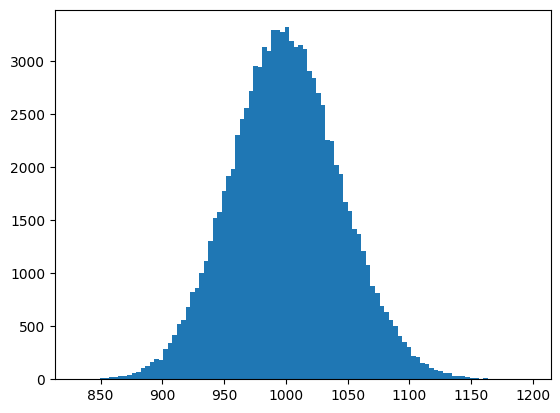

2026-06-30 12:06:08,556 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/distributed/worker.py", line 1165, in heartbeat
    response = await retry_operation(
  File "/opt/conda/lib/python3.10/site-packages/distributed/utils_comm.py", line 420, in retry_operation
    return await retry(
  File "/opt/conda/lib/python3.10/site-packages/distributed/utils_comm.py", line 399, in retry
    return await coro()
  File "/opt/conda/lib/python3.10/site-packages/distributed/core.py", line 1212, in send_recv_from_rpc
    return await send_recv(comm=comm, op=key, **kwarg

In [16]:
import matplotlib.pyplot as plt
print("Size of result vector=",len(result))
plt.hist(result,bins=100)